# PCLab#2 - Group 2 - Henricus Bracht Erdem Bayrakcioglu Leonard Fischbach

**Course:** 20598 - Finance with Big Data  
**Lab:** PC Lab #2 - Applying the CAPM (Week 3)

### 0.1 Imports

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from scipy.stats import norm
import matplotlib.dates as mdates


### CONSTANTS

In [64]:
TRADING_DAYS_PER_YEAR = 252
START_DATE = "2012-01-01"
MIN_OBS_FULL_SAMPLE = 126
MIN_OBS_BETA_WINDOW = 126
RF = 0.0
REFERENCE_TICKERS = ["AAPL", "BA", "T", "MGM", "AMZN", "IBM", "TSLA", "GOOG"] # These are the tickers that we saw in Lab #1

## Optional Task 0 — Web data (main dataset)

### 0.2 S&P 500 constituents from Wikipedia

In [65]:
from io import StringIO
import urllib.request

wikipedia_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
request = urllib.request.Request(
    wikipedia_url,
    headers={"User-Agent": "Mozilla/5.0 (PCLab CAPM student notebook)"},
)
with urllib.request.urlopen(request) as response:
    html = response.read().decode("utf-8")

sp500_tables = pd.read_html(StringIO(html))
sp500_constituents = sp500_tables[0][["Symbol", "Security", "GICS Sector"]].copy()

# yfinance uses "-" instead of "." (e.g. BRK.B -> BRK-B)
sp500_constituents["Symbol"] = sp500_constituents["Symbol"].str.replace(".", "-", regex=False)

print(sp500_constituents.head())
print("\nNumber of constituents:", len(sp500_constituents))
print("\nSector counts:")
print(sp500_constituents["GICS Sector"].value_counts())

  Symbol             Security             GICS Sector
0    MMM                   3M             Industrials
1    AOS          A. O. Smith             Industrials
2    ABT  Abbott Laboratories             Health Care
3   ABBV               AbbVie             Health Care
4    ACN            Accenture  Information Technology

Number of constituents: 503

Sector counts:
GICS Sector
Industrials               83
Financials                76
Information Technology    74
Health Care               60
Consumer Discretionary    47
Consumer Staples          33
Utilities                 31
Real Estate               30
Materials                 25
Communication Services    23
Energy                    21
Name: count, dtype: int64


In [66]:
# Exact same Security name? (usually none — classes have different labels)
print("tickers:", len(sp500_constituents))
print("unique Security:", sp500_constituents["Security"].nunique())

# Near-duplicates: strip "(Class A/B/C)"
company_base = (
    sp500_constituents["Security"]
    .str.replace(r"\s*\(Class .*\)\s*$", "", regex=True)
    .str.strip()
)
dual_class = sp500_constituents.assign(company_base=company_base)
dual_class = dual_class[dual_class["company_base"].duplicated(keep=False)].sort_values("company_base")

print("\nDual share classes:")
print(dual_class[["Symbol", "Security", "company_base"]])
print("\n# companies if one ticker per firm:", company_base.nunique())

tickers: 503
unique Security: 503

Dual share classes:
    Symbol                   Security     company_base
19   GOOGL    Alphabet Inc. (Class A)    Alphabet Inc.
20    GOOG    Alphabet Inc. (Class C)    Alphabet Inc.
204   FOXA  Fox Corporation (Class A)  Fox Corporation
205    FOX  Fox Corporation (Class B)  Fox Corporation
331   NWSA        News Corp (Class A)        News Corp
332    NWS        News Corp (Class B)        News Corp

# companies if one ticker per firm: 500


We have 503 tickers because we have seperate share classes for 3 companies. This is because some stocks that are issued are different in terms of voting rights in the general assembly. Otherwise, the company, the claims (e.g. dividends) and the stock trajectory are very similar. We will keep it because they are still both constituents based on free-float market cap of the S&P500, it would be arbitrary which one to filter out if we were to filter, and the effect is very small.

In [67]:
sp500_tickers = sp500_constituents["Symbol"].tolist()

reference_in_sp500 = [t for t in REFERENCE_TICKERS if t in sp500_tickers]
reference_not_in_sp500 = [t for t in REFERENCE_TICKERS if t not in sp500_tickers]

print("Reference tickers in today's S&P 500:", reference_in_sp500)
print("Reference tickers NOT in today's S&P 500:", reference_not_in_sp500)

Reference tickers in today's S&P 500: ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG']
Reference tickers NOT in today's S&P 500: []


All eight Lab #1 reference tickers are in today's S&P 500 constituents in this scrape. This makes sense as they are some of the larger American companies. 

### 0.3 Download adjusted prices with yfinance

In [68]:
tickers_to_download = sorted(set(sp500_tickers + REFERENCE_TICKERS + ["^GSPC"]))

raw_price_data = yf.download(
    tickers_to_download,
    start=START_DATE,
    auto_adjust=True,
    progress=False,
    threads=True,
)

stock_price_data = raw_price_data["Close"].copy()

stock_price_data = stock_price_data.rename(columns={"^GSPC": "sp500"})
stock_price_data = stock_price_data.sort_index()
stock_price_data.index.name = "Date"

# Drop columns that failed to download (all NaN)
stock_price_data = stock_price_data.dropna(axis=1, how="all")

print(stock_price_data.shape)
print(stock_price_data.head())

(3702, 504)
Ticker              A       AAPL  ABBV  ABNB        ABT       ACGL        ACN  \
Date                                                                            
2012-01-03  23.045282  12.299739   NaN   NaN  20.195404  11.879891  40.365807   
2012-01-04  22.862078  12.365838   NaN   NaN  20.117083  11.664356  40.350555   
2012-01-05  23.373777  12.503125   NaN   NaN  20.070793  11.886231  39.580589   
2012-01-06  23.626463  12.633826   NaN   NaN  19.889204  11.873553  39.511997   
2012-01-09  24.245560  12.613788   NaN   NaN  19.885641  11.787971  39.443367   

Ticker           ADBE        ADI        ADM  ...       WYNN        XEL  \
Date                                         ...                         
2012-01-03  28.570000  26.094524  19.166847  ...  82.520821  16.826439   
2012-01-04  28.280001  26.058317  19.485298  ...  81.101677  16.715658   
2012-01-05  28.480000  26.174200  19.399050  ...  80.254524  16.789509   
2012-01-06  28.719999  26.000376  19.286266  ...  

Now, we have all the 504 adjusted closing prices. It includes the 503 company stocks and the S&P500 index. Adjusted means that they are adjusted for the dividend payment and stock splits. In a stock split, the amount of stock increases without the market cap increasing. Therefore, we have more stock which makes the prices drop. This would blur the image in hindsight, therefore we pretend that the amount of stock has not changed and is stable at the current amount. Additionally, once a company issues dividend, the stock will lose the value of that dividend payment. For CAPM, we want to have **returns** that are not influenced by fake-crashes through aforementioned reasons.

### 0.4 Describe the sample

In [69]:
stock_ticker_columns = [c for c in stock_price_data.columns if c != "sp500"]

print("Start date:", stock_price_data.index.min().date())
print("End date:", stock_price_data.index.max().date())
print("Number of trading days:", len(stock_price_data))
print("Number of stock columns:", len(stock_ticker_columns))
print("Market column present:", "sp500" in stock_price_data.columns)

missing_share = stock_price_data[stock_ticker_columns].isna().mean()
print("\nAverage missing share across stocks:", round(missing_share.mean(), 4))
print("Stocks with any missing values:", int((missing_share > 0).sum()))

enough_obs = stock_price_data[stock_ticker_columns].notna().sum() >= MIN_OBS_FULL_SAMPLE
print(f"Stocks with at least {MIN_OBS_FULL_SAMPLE} non-missing prices:", int(enough_obs.sum()))

Start date: 2012-01-03
End date: 2026-09-23
Number of trading days: 3702
Number of stock columns: 503
Market column present: True

Average missing share across stocks: 0.0522
Stocks with any missing values: 458
Stocks with at least 126 non-missing prices: 501


## Task #1 — Visualization / first CAPM step

### 1.1 Daily returns

In [70]:
stock_daily_returns = stock_price_data[stock_ticker_columns].pct_change()
market_daily_returns = stock_price_data["sp500"].pct_change()

print(stock_daily_returns.head())
print("\nMarket returns head:")
print(market_daily_returns.head())

Ticker             A      AAPL  ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                       
2012-01-03       NaN       NaN   NaN   NaN       NaN       NaN       NaN   
2012-01-04 -0.007950  0.005374   NaN   NaN -0.003878 -0.018143 -0.000378   
2012-01-05  0.022382  0.011102   NaN   NaN -0.002301  0.019022 -0.019082   
2012-01-06  0.010811  0.010453   NaN   NaN -0.009047 -0.001067 -0.001733   
2012-01-09  0.026204 -0.001586   NaN   NaN -0.000179 -0.007208 -0.001737   

Ticker          ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2012-01-03       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2012-01-04 -0.010150 -0.001388  0.016615  ... -0.010994 -0.017197 -0.006584   
2012-01-05  0.007072  0.004447 -0.004426  ... -0.005824 -0.010446  0.004418   
2012-01-06  0.008427 -0.006641 -0.005814  ...  0.012780 -0.035186 -0.002

CAPM relates *returns*, not price levels. Prices are non-stationary and hard to compare across stocks; daily percentage changes put everything on a common scale for beta estimation.

### 1.2 Scatter plots: reference stocks vs market

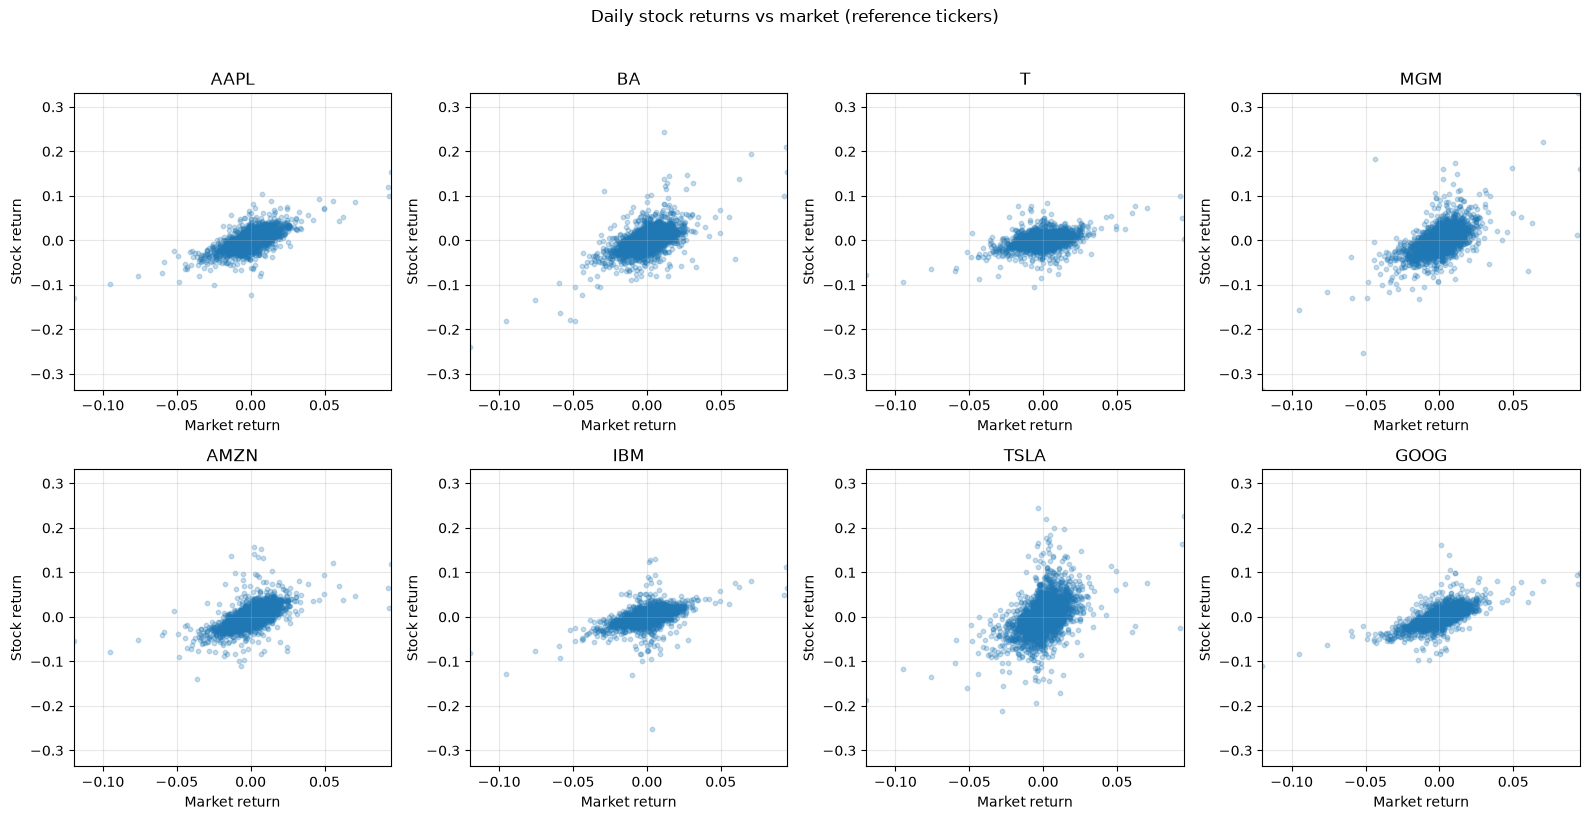

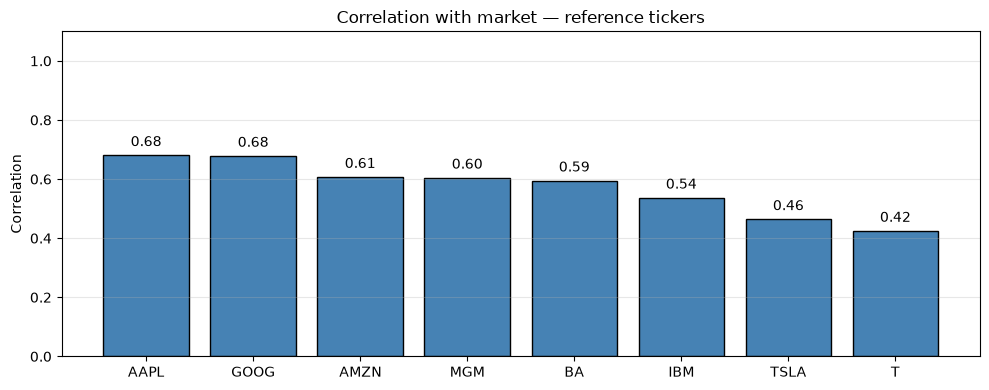

In [71]:
# Same axis limits for all panels so clouds are comparable
aligned_by_ticker = {}
reference_correlations = {}

for ticker in REFERENCE_TICKERS:
    if ticker not in stock_daily_returns.columns:
        continue
    aligned = pd.concat(
        [market_daily_returns, stock_daily_returns[ticker]],
        axis=1,
        join="inner",
    ).dropna()
    aligned.columns = ["market", "stock"]
    aligned_by_ticker[ticker] = aligned
    reference_correlations[ticker] = aligned["market"].corr(aligned["stock"])

all_aligned = pd.concat(aligned_by_ticker.values(), ignore_index=True)
x_min, x_max = all_aligned["market"].min(), all_aligned["market"].max()
y_min, y_max = all_aligned["stock"].min(), all_aligned["stock"].max()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(REFERENCE_TICKERS):
    ax = axes[i]
    if ticker not in aligned_by_ticker:
        ax.set_title(f"{ticker} (missing)")
        ax.axis("off")
        continue

    aligned = aligned_by_ticker[ticker]
    ax.scatter(aligned["market"], aligned["stock"], alpha=0.25, s=10)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(ticker)
    ax.set_xlabel("Market return")
    ax.set_ylabel("Stock return")
    ax.grid(True, alpha=0.3)

plt.suptitle("Daily stock returns vs market (reference tickers)", y=1.02)
plt.tight_layout()
plt.show()

# Correlation bar chart for easier comparison across tickers
corr_series = pd.Series(reference_correlations).reindex(REFERENCE_TICKERS).dropna()
corr_series.sort_values(inplace=True, ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(corr_series.index, corr_series.values, color="steelblue", edgecolor="black")
for bar, value in zip(bars, corr_series.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.title("Correlation with market — reference tickers")
plt.ylabel("Correlation")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


Although all the eight stocks are all positively correlated with the market, the degree of this correlation varies significantly, with AAPL and GOOG showing the highest correlations at about 0.68, and T and TSLA having the lowest at about 0.42 and 0.46.

TSLA is especially interesting because its scatter plot shows that its returns often respond strongly to changes in the market, but the points are also very spread out. There are a great many substantial movements in TSLA even when the market return is near zero. This is why its correlation with the market is only moderate even though it appears to be sensitive to market movements.

This is also the reason why correlation and market sensitivity are not identical. Correlation indicates how closely the two returns move in relation to one another, whereas the following task employs an OLS regression to calculate beta and thus measure the stock's sensitivity to movements in the market.

### 1.3 Full-universe correlations vs market

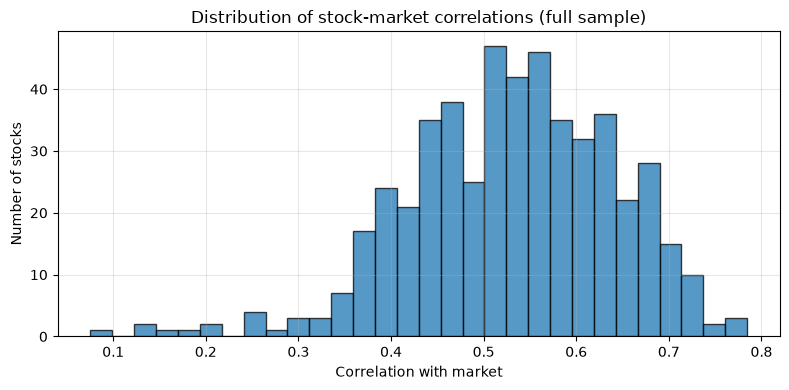

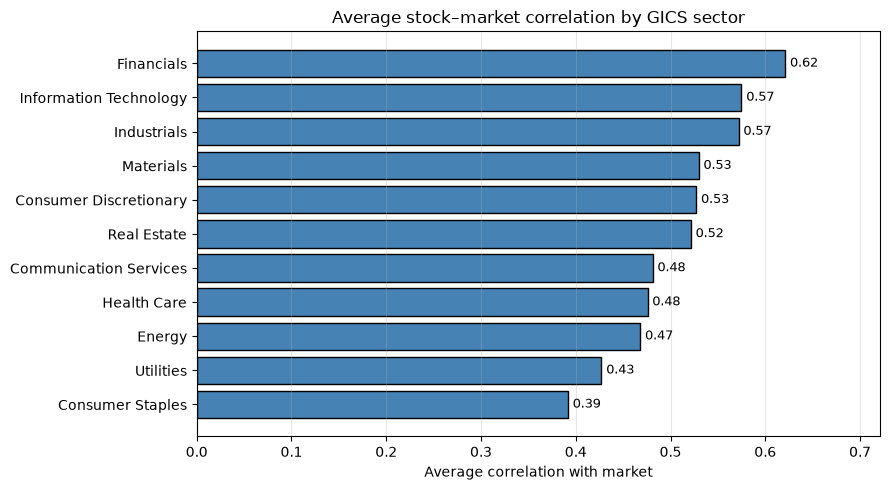

In [72]:
market_correlations = stock_daily_returns.corrwith(market_daily_returns).dropna().sort_values()

plt.figure(figsize=(8, 4))
plt.hist(market_correlations, bins=30, edgecolor="black", alpha=0.75)
plt.title("Distribution of stock-market correlations (full sample)")
plt.xlabel("Correlation with market")
plt.ylabel("Number of stocks")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Average market correlation by GICS sector
corr_by_sector = (
    market_correlations.rename("correlation")
    .to_frame()
    .join(sp500_constituents.set_index("Symbol")["GICS Sector"])
    .dropna()
)
sector_avg_corr = corr_by_sector.groupby("GICS Sector")["correlation"].mean().sort_values()

plt.figure(figsize=(9, 5))
bars = plt.barh(sector_avg_corr.index, sector_avg_corr.values, color="steelblue", edgecolor="black")
for bar, value in zip(bars, sector_avg_corr.values):
    plt.text(value + 0.005, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
             va="center", fontsize=9)
plt.title("Average stock–market correlation by GICS sector")
plt.xlabel("Average correlation with market")
plt.xlim(0, min(1.0, sector_avg_corr.max() + 0.1))
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


In the case of the entire S&P 500 sample, there is a obvious common market factor. Nearly the whole of the distribution is above zero, which shows that individual stocks generally tend to move in the same direction as the market. The majority of the correlations are found between about 0.4 and 0.7. This provides the first sign of the systematic market factor which is at the heart of the CAPM.

Meanwhile, the market is clearly unable to account for all aspects. The correlations are a far away from one, which shows that individual stocks do not act as copies of the index. Returns on stocks are also influenced by firm-specific and sector-specific factors and may therefore experience big movements even if the overall market only moves a little.

The fact that correlations are so widely spread is also interesting. While some stocks have correlations below 0.3, others are nearly 0.8. To some extent, this difference can be explained by looking at the various GICS sectors. Financials have the highest average market correlation, at about 0.62, then Information Technology and Industrials come next at about 0.57. On the other hand, Utilities and Consumer Staples have much lower average correlations, approximately 0.43 and 0.39 respectively. This is in line with the view that defensive sectors tend to be less closely connected with general market movements, whereas more cyclical sectors tend to move more in line with the market.

As already mentioned, a correlation does not imply market sensitivity. While correlation shows how closely a stock's movements match those of the market, it does not indicate the intensity of the stock's reaction to a particular market movement. It is therefore possible for a volatile stock to have only a moderate correlation with the market and yet to react strongly when the market moves. This point is looked at in more detail in Task #2, where alpha and beta are estimated using OLS regressions.

## Task #2 — Alpha & beta (full S&P 500)

### 2.1 CAPM estimation helper

In [73]:
def estimate_capm(stock_returns, market_returns):
    # Create a dataframe with the stock and market returns to drop na
    df = pd.DataFrame({"stock": stock_returns, "market": market_returns}).dropna()
    # Estimate the CAPM OLS model
    model = sm.OLS(df["stock"], sm.add_constant(df["market"])).fit()

    return {
        "alpha": model.params["const"],
        "beta": model.params.iloc[1],
        "alpha_pvalue": model.pvalues["const"],
        "beta_pvalue": model.pvalues.iloc[1],
        "r_squared": model.rsquared,
        "n_obs": int(model.nobs),
        "residual_std": float(model.resid.std()),
        "residuals": model.resid,
    }

### 2.2 Estimate CAPM for all stocks with enough observations

In [74]:
capm_rows = []
capm_residuals = {}

for ticker in stock_ticker_columns:
    n_valid = stock_daily_returns[ticker].notna().sum()
    if n_valid < MIN_OBS_FULL_SAMPLE:
        continue

    result = estimate_capm(stock_daily_returns[ticker], market_daily_returns)
    if result is None:
        continue

    capm_residuals[ticker] = result["residuals"]
    capm_rows.append({
        "ticker": ticker,
        "alpha": result["alpha"],
        "beta": result["beta"],
        "alpha_pvalue": result["alpha_pvalue"],
        "beta_pvalue": result["beta_pvalue"],
        "r_squared": result["r_squared"],
        "n_obs": result["n_obs"],
        "residual_std": result["residual_std"],
    })

capm_results = pd.DataFrame(capm_rows).set_index("ticker").sort_values("beta")

### 2.3 Statistical significance at 5%

In [75]:
# Calculate the percentage of significant alphas and betas in the full sample by calculating the mean of boolean (either 1 or 0)
alpha_sig_full = (capm_results["alpha_pvalue"] < 0.05).mean()
beta_sig_full = (capm_results["beta_pvalue"] < 0.05).mean()

# Filtering the reference tickers
reference_capm = capm_results.reindex([t for t in REFERENCE_TICKERS if t in capm_results.index])
alpha_sig_ref = (reference_capm["alpha_pvalue"] < 0.05).mean()
beta_sig_ref = (reference_capm["beta_pvalue"] < 0.05).mean()

print(f"Full sample: {100 * alpha_sig_full:.1f}% significant alphas, {100 * beta_sig_full:.1f}% significant betas")
print(f"Reference subset: {100 * alpha_sig_ref:.1f}% significant alphas, {100 * beta_sig_ref:.1f}% significant betas")
print("\nReference detail:")
print(reference_capm[["alpha", "alpha_pvalue", "beta", "beta_pvalue", "r_squared"]])

Full sample: 7.0% significant alphas, 100.0% significant betas
Reference subset: 25.0% significant alphas, 100.0% significant betas

Reference detail:
           alpha  alpha_pvalue      beta    beta_pvalue  r_squared
ticker                                                            
AAPL    0.000426      0.047806  1.159635   0.000000e+00   0.462883
BA     -0.000120      0.692649  1.305969   0.000000e+00   0.353146
T       0.000100      0.621100  0.548685  1.718544e-161   0.179938
MGM    -0.000126      0.720095  1.539935   0.000000e+00   0.364887
AMZN    0.000473      0.077863  1.187903   0.000000e+00   0.367921
IBM    -0.000100      0.655315  0.826867  1.052646e-274   0.287712
TSLA    0.001212      0.021011  1.593510  1.368077e-196   0.214982
GOOG    0.000366      0.083686  1.131110   0.000000e+00   0.459638


The beta estimates are found to be significant at the 5% level for all of the stocks in our sample. This proves that there is a statistically significant relationship between market movements and the returns on individual stocks. It should be noted, though, that a significant beta does not mean that the CAPM correctly predicts expected returns, something which we test later on.

A significant alpha is found in only 7% of the stocks and it is therefore not possible to reject the idea that the alpha is zero for the majority of the stocks. Because we carry out hundreds of tests at the 5 per cent level of significance, it is also possible for some of the significant alphas to arise by chance. Of the eight reference stocks, merely AAPL and TSLA have significant alphas at the 5 per cent level.

The differences in the R-squared values are also important: For example, the market accounts for about 46% of the variation in the returns of AAPL and GOOG, whereas for TSLA it is only about 21%. This confirms our previous observation that although TSLA reacts strongly to the market it also has a considerable amount of variation which is not accounted for by movements in the market.

### 2.4 Beta distribution

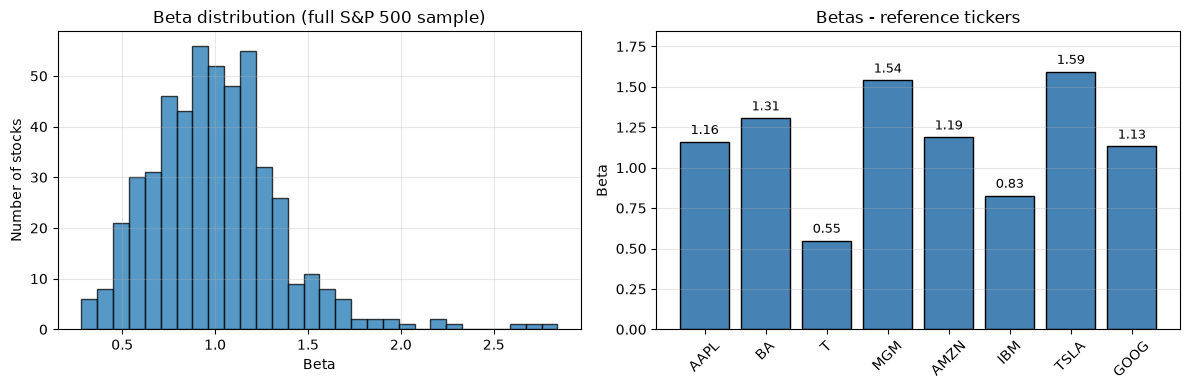

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(capm_results["beta"], bins=30, edgecolor="black", alpha=0.75)
axes[0].set_title("Beta distribution (full S&P 500 sample)")
axes[0].set_xlabel("Beta")
axes[0].set_ylabel("Number of stocks")
axes[0].grid(True, alpha=0.3)

ref_betas = reference_capm["beta"].reindex(REFERENCE_TICKERS).dropna()
bars = axes[1].bar(ref_betas.index, ref_betas.values, color="steelblue", edgecolor="black")
for bar, value in zip(bars, ref_betas.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].set_title("Betas - reference tickers")
axes[1].set_ylabel("Beta")
axes[1].set_ylim(0, ref_betas.max() + 0.25)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The beta distribution indicates that the majority of the stocks in the S&P 500 have a beta near one. This implies that most of the stocks react to changes in the market in a way that is similar to the market as a whole. Yet there is still a good deal of variation between companies, with some stocks having betas much lower than one and a smaller number having betas above 1.5 or even above 2. The distribution also shows a right tail, which demonstrates that a few stocks respond strongly to changes in the market.

The differences in beta are clearly shown by reference stocks: TSLA and MGM have the highest values, namely about 1.59 and 1.54 respectively. Our estimated regressions show that, for every 1% move in the market, TSLA and MGM are therefore on average associated with a movement of about 1.59% and 1.54% in the same direction respectively. BA also has a relatively high beta of 1.31. On the other hand, T has the lowest beta at around 0.55, with IBM coming next at about 0.83, which means that their returns tend to respond less strongly to changes in the market.

It is especially interesting to compare these results with those from Task #1. TSLA had one of the lowest market correlations among the reference stocks, with c. 0.46, but it now has the highest estimated beta. Again, this is not a contradiction since correlation shows how closely the price of a stock moves in relation to the market, while beta indicates the extent of the stock's reaction to market movements. Because Tesla experiences big fluctuations in return and has many movements that are not closely linked to the market, its correlation is low. Yet when it does move in line with the market, the magnitude of those movements is large, leading to a high beta.

The findings explain therefore the difference between beta and correlation and show that beta is the appropriate risk measure within the CAPM. While beta reflects a stock's exposure to systematic market risk rather than just indicating how closely the two return series move together, stocks having a beta greater than one are more sensitive to changes in the market whereas those with a low beta are less sensitive.

### 2.5 Alpha distribution (daily units)

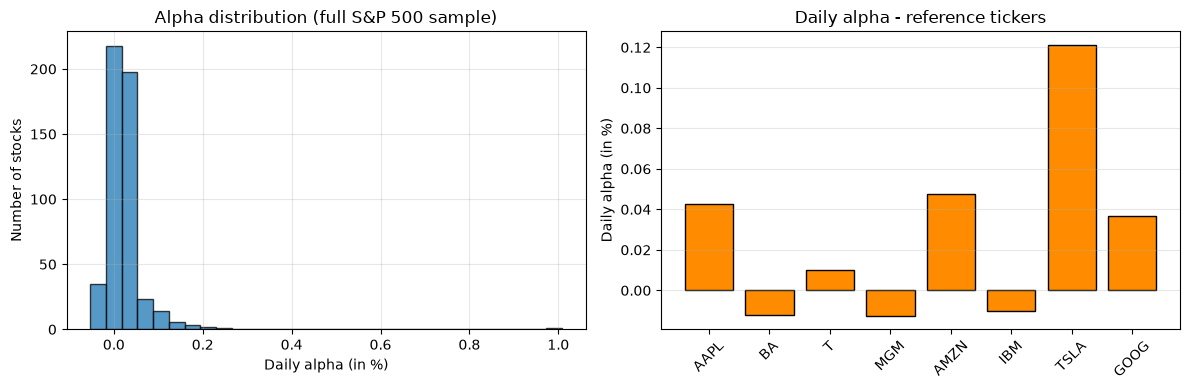

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    capm_results["alpha"] * 100,
    bins=30,
    edgecolor="black",
    alpha=0.75
)
axes[0].set_title("Alpha distribution (full S&P 500 sample)")
axes[0].set_xlabel("Daily alpha (in %)")
axes[0].set_ylabel("Number of stocks")
axes[0].grid(True, alpha=0.3)

ref_alphas = (
    reference_capm["alpha"]
    .reindex(REFERENCE_TICKERS)
    .dropna()
    * 100
)

axes[1].bar(
    ref_alphas.index,
    ref_alphas.values,
    color="darkorange",
    edgecolor="black"
)
axes[1].set_title("Daily alpha - reference tickers")
axes[1].set_ylabel("Daily alpha (in %)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The alphas obtained from the regressions, since they are calculated using daily returns, are themselves on a daily basis. That is why we show them as daily percentages so that the size of them is easier to understand. The distribution is concentrated within a fairly narrow range, even though it has a distinct right tail with a number of unusually large positive alpha estimates.

Of the reference stocks, TSLA has the highest estimated alpha at about 0.12% per day, whereas AAPL and AMZN have positive daily alphas of about 0.04 to 0.05%. BA, MGM and IBM have slightly negative estimated alphas. Yet the magnitude of the estimated alpha by itself is not sufficient to indicate that a stock achieves abnormal returns. As stated in the earlier section, only AAPL and TSLA have alphas that are statistically significant at the 5% level among the reference stocks.

The p-values should therefore be used when interpreting the alpha. In most cases the estimated alphas are not statistically different from zero, although a small number of stocks have higher positive estimates.

### 2.6 Residuals

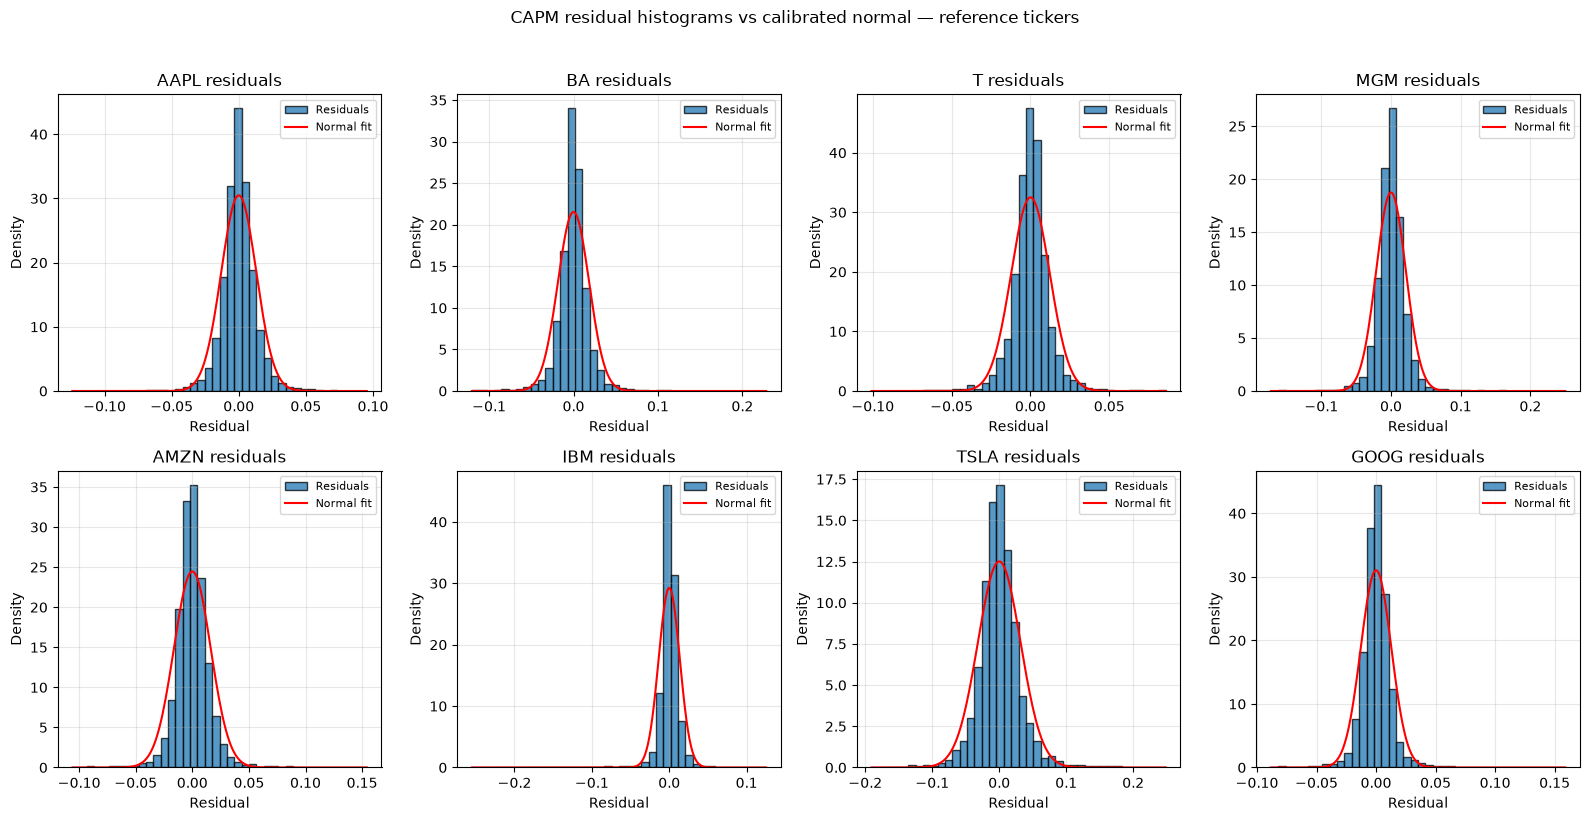

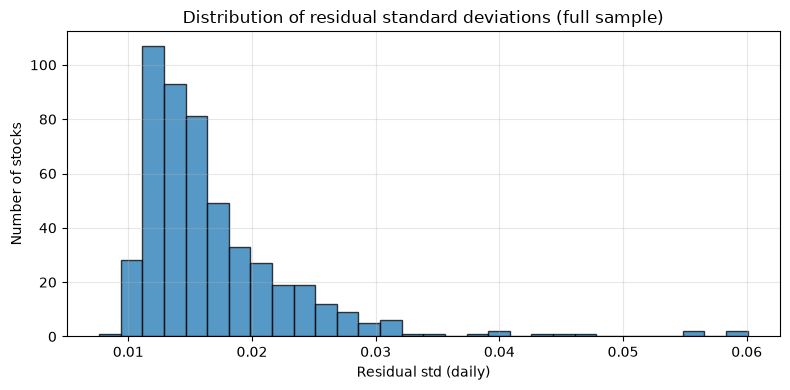

In [78]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(REFERENCE_TICKERS):
    ax = axes[i]
    if ticker not in capm_residuals:
        ax.set_title(f"{ticker} (missing)")
        ax.axis("off")
        continue

    residuals = capm_residuals[ticker]
    mu = residuals.mean()
    sigma = residuals.std()

    # density=True so the calibrated normal PDF is on the same scale
    ax.hist(residuals, bins=40, density=True, edgecolor="black", alpha=0.75, label="Residuals")

    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x, norm.pdf(x, loc=mu, scale=sigma), color="red", linewidth=1.5, label="Normal fit")

    ax.set_title(f"{ticker} residuals")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("CAPM residual histograms vs calibrated normal — reference tickers", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(capm_results["residual_std"], bins=30, edgecolor="black", alpha=0.75)
plt.title("Distribution of residual standard deviations (full sample)")
plt.xlabel("Residual std (daily)")
plt.ylabel("Number of stocks")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The portion of each stock's daily return which cannot be accounted for by its estimated level of exposure to the market is known as the residual. Positive residuals show the situations in which the stock outperformed the prediction of the market model, and negative residuals indicate the reverse. The residuals are centred near zero, something that is to be expected in the case of an OLS regression with an intercept.

Because we can see that the distributions differ from the normal curves that have been fitted to them with a higher concentration around zero and with relatively long tails and extreme values, we can conclude that unusual movements in firm-specific returns happen more often than a normal distribution would suggest. The effect is especially clear in the case of stocks like TSLA, MGM and BA.

Wider distributions mean more variation in returns there is after allowing for movements in the market and therefore greater the idiosyncratic (company-specific) volatility.

This confirms our previous findings for Tesla. Although its beta of about 1.59 indicates a high sensitivity to market movements, its R-squared of only about 0.21 shows that the market accounts for only a relatively small portion of the variation in its daily returns. The broadness of the residual distribution shows the extent of the firm-specific element. 

Looking at the residual standard deviations for the entire S&P 500, we can see that the amount of return volatility that cannot be explained varies considerably among firms.

### 2.7 High-beta equal-weight portfolio (top 4 from full sample)

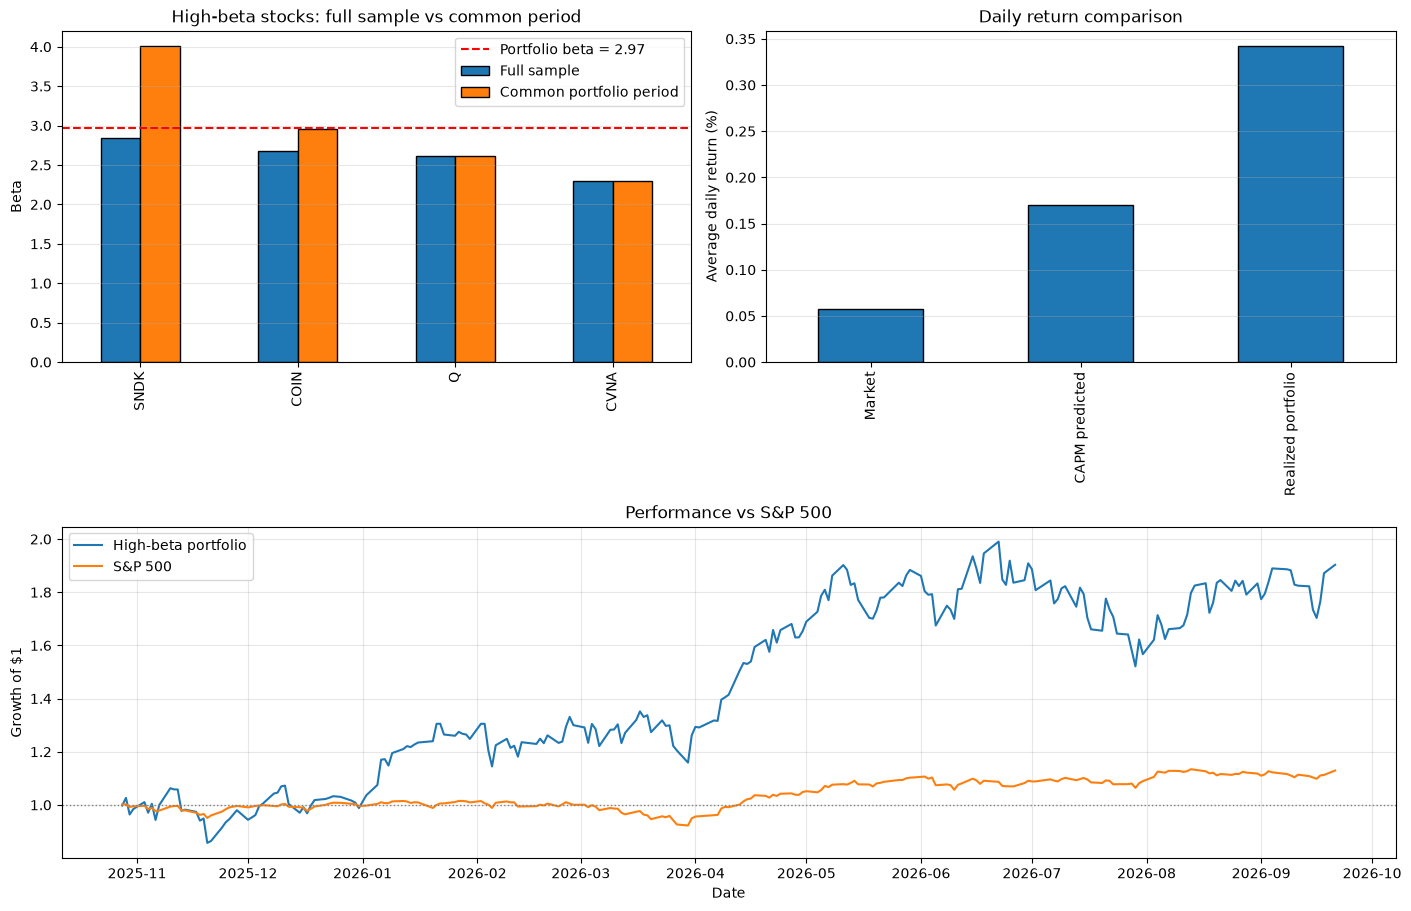

In [79]:
# Select 4 highest-beta stocks
HIGH_BETA_TICKERS = capm_results["beta"].nlargest(4).index.tolist()

# Full-sample betas used to select the four stocks
full_sample_betas = capm_results.loc[HIGH_BETA_TICKERS, "beta"]

# Common period for all four stocks
high_beta_returns = stock_daily_returns[HIGH_BETA_TICKERS].dropna()
portfolio_daily_returns = high_beta_returns.mean(axis=1)

# Same market dates
market_returns_portfolio_period = market_daily_returns.loc[portfolio_daily_returns.index]

# Portfolio CAPM
portfolio_result = estimate_capm(portfolio_daily_returns, market_returns_portfolio_period)

portfolio_beta = portfolio_result["beta"]

mean_market_daily = market_returns_portfolio_period.mean()
predicted_daily_return = portfolio_beta * mean_market_daily
realized_mean_daily = portfolio_daily_returns.mean()

# Re-estimate individual betas over the same common period
common_betas = {}

for ticker in HIGH_BETA_TICKERS:
    common_betas[ticker] = estimate_capm(high_beta_returns[ticker], market_returns_portfolio_period)["beta"]

common_betas = pd.Series(common_betas)

# Compare full-sample and common-period betas
beta_comparison = pd.DataFrame({"Full sample": full_sample_betas, "Common portfolio period": common_betas})

# Performance
portfolio_performance = (1 + portfolio_daily_returns).cumprod()
market_performance = (1 + market_returns_portfolio_period).cumprod()

# Plot
fig, axes = plt.subplot_mosaic([["beta", "returns"], ["performance", "performance"]], figsize=(14, 9), constrained_layout=True)

# Betas: full sample vs common portfolio period
beta_comparison.plot.bar(ax=axes["beta"], edgecolor="black")

axes["beta"].axhline(portfolio_beta, color="red", linestyle="--", label=f"Portfolio beta = {portfolio_beta:.2f}")

axes["beta"].set_title("High-beta stocks: full sample vs common period")
axes["beta"].set_ylabel("Beta")
axes["beta"].grid(axis="y", alpha=0.3)
axes["beta"].legend()

# Daily return comparison
daily_return_comparison = pd.Series({"Market": mean_market_daily, "CAPM predicted": predicted_daily_return, "Realized portfolio": realized_mean_daily}) * 100

daily_return_comparison.plot.bar(ax=axes["returns"], edgecolor="black")

axes["returns"].set_title("Daily return comparison")
axes["returns"].set_ylabel("Average daily return (%)")
axes["returns"].grid(axis="y", alpha=0.3)

# Performance
axes["performance"].plot(portfolio_performance, label="High-beta portfolio")
axes["performance"].plot(market_performance, label="S&P 500")
axes["performance"].axhline(1, color="gray", linestyle=":", linewidth=1)
axes["performance"].set_title("Performance vs S&P 500")
axes["performance"].set_xlabel("Date")
axes["performance"].set_ylabel("Growth of $1")
axes["performance"].grid(alpha=0.3)
axes["performance"].legend()

plt.show()

The stocks were chosen on the basis of their full-sample betas. Upon re-estimating their betas during the common portfolio period, some of the estimates change significantly. For instance, that of SNDK rises from approximately 2.84 to 4.00. This demonstrates that beta is not necessarily constant over time and that it depends on the period of estimation. A robustness check has been performed below.

For the period in question, the portfolio which is equally weighted has a beta of approximately 2.97. The average daily return of the market is about 0.057%, leading to a predicted portfolio return of roughly 0.170% per day according to the CAPM. The actual average return of the portfolio is much higher at about 0.342%. Hence, the portfolio's high level of exposure to systematic market risk accounts for some of its high return, but the return achieved in this sample is still above the CAPM prediction.

The fact that the cumulative performance is shown also highlights the risks involved in achieving this higher return. Although the high-beta portfolio greatly outperforms the S&P 500 during the usual sample period, its value varies much more and suffers significantly larger drawdowns. This is in keeping with the aim of creating a high-risk portfolio, since the higher historical return has been achieved together with a great deal of exposure to market movements and overall volatility.

Nevertheless, we should take care when doing this comparison. The common period for the portfolio is fairly short, and the four stocks were chosen on the basis of beta estimates derived from historical data. The outcome is thus an example based on in-sample data and does not prove that the portfolio would systematically beat the CAPM forecast in the future.

### Robustness check

In [80]:
# Check: full-sample betas can differ from portfolio beta because each stock
# may have a different estimation window. Re-estimate each stock beta on the
# same overlapping dates used for the EW portfolio — then the average should
# match portfolio_beta (EW + OLS is linear).
common_market = market_daily_returns.loc[portfolio_daily_returns.index]

betas_common_window = {}
for ticker in HIGH_BETA_TICKERS:
    result = estimate_capm(stock_daily_returns[ticker].loc[portfolio_daily_returns.index], common_market)
    betas_common_window[ticker] = result["beta"]

betas_common_window = pd.Series(betas_common_window)
avg_beta_common_window = betas_common_window.mean()

print("Full-sample betas (from capm_results):")
print(capm_results.loc[HIGH_BETA_TICKERS, "beta"].round(4))
print(f"Average of full-sample betas: {capm_results.loc[HIGH_BETA_TICKERS, 'beta'].mean():.4f}")

print("\nBetas re-estimated on common portfolio window:")
print(betas_common_window.round(4))
print(f"Average of common-window betas: {avg_beta_common_window:.4f}")
print(f"Portfolio beta:                 {portfolio_beta:.4f}")
print(f"Difference (avg - portfolio):   {avg_beta_common_window - portfolio_beta:.6f}")


Full-sample betas (from capm_results):
ticker
SNDK    2.8430
COIN    2.6790
Q       2.6170
CVNA    2.2939
Name: beta, dtype: float64
Average of full-sample betas: 2.6082

Betas re-estimated on common portfolio window:
SNDK    4.0036
COIN    2.9525
Q       2.6170
CVNA    2.2908
dtype: float64
Average of common-window betas: 2.9660
Portfolio beta:                 2.9660
Difference (avg - portfolio):   0.000000


## Task #3 Testing the CAPM theory

### 3.1 Estimate lagged yearly betas

In [ ]:
def build_yearly_capm_results(beta_window=TRADING_DAYS_PER_YEAR, min_obs=MIN_OBS_BETA_WINDOW):
    market_dates = market_daily_returns.dropna().index.sort_values()
    years = sorted(stock_daily_returns.index.year.unique())
    rows = []

    for year in years:
        year_start = pd.Timestamp(f"{year}-01-01")
        prior_dates = market_dates[market_dates < year_start]

        # Need enough history before year y to estimate beta
        if len(prior_dates) < beta_window:
            continue

        # Fixed window: last beta_window market days before 1 Jan of year y
        window_dates = prior_dates[-beta_window:]
        market_window = market_daily_returns.loc[window_dates]

        # Returns during year y (for average return and CAPM prediction)
        year_mask = stock_daily_returns.index.year == year
        stock_year = stock_daily_returns.loc[year_mask]
        market_year = market_daily_returns.loc[year_mask]

        if stock_year.empty or market_year.dropna().empty:
            continue

        average_market_daily_return = market_year.mean()

        for ticker in stock_ticker_columns:
            # Lagged beta on the shared pre-year window
            stock_window = stock_daily_returns[ticker].reindex(window_dates)
            if stock_window.notna().sum() < min_obs:
                continue

            result = estimate_capm(stock_window, market_window)
            if result["n_obs"] < min_obs:
                continue

            lagged_beta = result["beta"]
            n_beta_obs = result["n_obs"]

            # Average stock return in year y
            stock_y = stock_year[ticker].dropna()
            if stock_y.empty:
                continue

            average_stock_daily_return = stock_y.mean()
            # CAPM prediction: beta from y-1 times average market return in y
            predicted_average_daily_return = lagged_beta * average_market_daily_return

            # Annualize both average daily returns the same way (* 252)
            actual_annualized_average_return = average_stock_daily_return * TRADING_DAYS_PER_YEAR
            predicted_annualized_average_return = predicted_average_daily_return * TRADING_DAYS_PER_YEAR
            prediction_error = actual_annualized_average_return - predicted_annualized_average_return

            rows.append({
                "year": year,
                "ticker": ticker,
                "lagged_beta": lagged_beta,
                "average_stock_daily_return": average_stock_daily_return,
                "average_market_daily_return": average_market_daily_return,
                "predicted_average_daily_return": predicted_average_daily_return,
                "actual_annualized_average_return": actual_annualized_average_return,
                "predicted_annualized_average_return": predicted_annualized_average_return,
                "prediction_error": prediction_error,
                "beta_estimation_observations": n_beta_obs,
            })

    return pd.DataFrame(rows)


yearly_capm_results = build_yearly_capm_results(beta_window=TRADING_DAYS_PER_YEAR)
yearly_capm_results.head()


,year,ticker,lagged_beta,average_stock_daily_return,average_market_daily_return,predicted_average_daily_return,actual_annualized_average_return,predicted_annualized_average_return,prediction_error,beta_estimation_observations
0,2014,A,1.155473,0.000129,0.000454,0.000524,0.032406,0.132122,-0.099716,252
1,2014,AAPL,0.625678,0.001447,0.000454,0.000284,0.364520,0.071543,0.292977,252
2,2014,ABBV,1.145469,0.001098,0.000454,0.000520,0.276760,0.130978,0.145781,251
3,2014,ABT,1.004822,0.000773,0.000454,0.000456,0.194891,0.114896,0.079995,252
4,2014,ACGL,0.747417,-0.000011,0.000454,0.000339,-0.002742,0.085463,-0.088205,252


### 3.2 Average stock return vs CAPM prediction

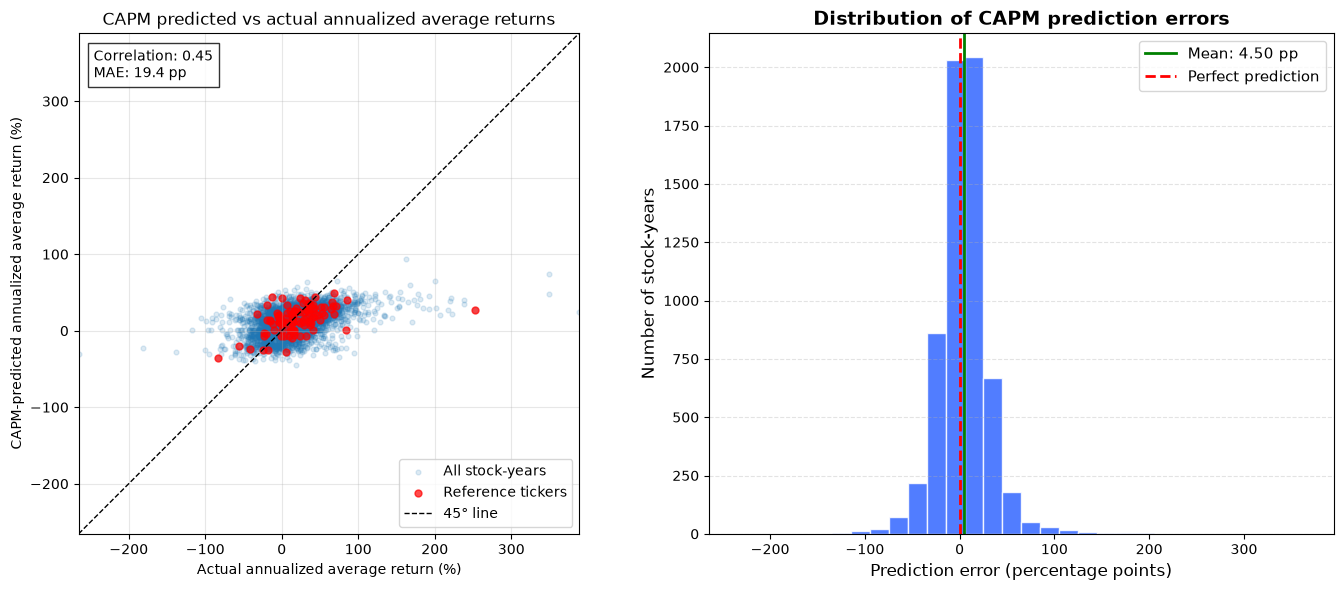

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data: Convert annualized returns to percent for readability
actual_returns = yearly_capm_results["actual_annualized_average_return"] * 100
predicted_returns = yearly_capm_results["predicted_annualized_average_return"] * 100

# Scatter plot for all stock-years (all available data)
axes[0].scatter(
    actual_returns,
    predicted_returns,
    alpha=0.15,  # Lower opacity for overlapping points
    s=12,        # Smaller marker size for clarity
    label="All stock-years"
)

# Highlight a subset of reference tickers, if present, in red
ref_mask = yearly_capm_results["ticker"].isin(REFERENCE_TICKERS)
if ref_mask.any():
    axes[0].scatter(
        actual_returns.loc[ref_mask],
        predicted_returns.loc[ref_mask],
        alpha=0.7,   # More visible points
        s=25,
        color="red",
        label="Reference tickers"
    )

# Draw a dashed 45-degree reference line, representing perfect prediction
lims = [min(actual_returns.min(), predicted_returns.min()), max(actual_returns.max(), predicted_returns.max())]
axes[0].plot(lims, lims, "k--", linewidth=1, label="45° line")  # black dashed line

# Compute the correlation coefficient between actual and predicted returns
prediction_correlation = yearly_capm_results[["actual_annualized_average_return", "predicted_annualized_average_return"]].corr().iloc[0, 1]

# Compute the Mean Absolute Error (MAE) of the CAPM prediction
mean_absolute_error = yearly_capm_results["prediction_error"].abs().mean()

# Display correlation and MAE info in the upper left of the plot, on a white background box
axes[0].text(
    0.03, 0.97,
    f"Correlation: {prediction_correlation:.2f}\nMAE: {mean_absolute_error * 100:.1f} pp",
    transform=axes[0].transAxes, va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

# Label axes and set title for the first subplot
axes[0].set_xlabel("Actual annualized average return (%)")
axes[0].set_ylabel("CAPM-predicted annualized average return (%)")
axes[0].set_title("CAPM predicted vs actual annualized average returns")
axes[0].legend()

# Set the plot limits and make axes have equal scaling for good 1:1 visualization
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)


#Histogram of CAPM prediction errors

# Calculate prediction errors between actual and predicted annualized returns, in percentage points
prediction_errors = yearly_capm_results["prediction_error"] * 100

# Plot histogram of errors on the second subplot
n, bins, patches = axes[1].hist(
    prediction_errors,
    bins=30,
    color="#3366ff",     # Light blue color
    edgecolor="white",   # White edge for clarity
    alpha=0.85           # Some transparency
)

# Compute and draw a vertical line for the mean error, in green
mean_error = prediction_errors.mean()
axes[1].axvline(
    mean_error,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Mean: {mean_error:.2f} pp"
)

# Draw a vertical dashed red line at zero, which would correspond to perfect prediction
axes[1].axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

# Set axis labels and plot title, using slightly larger or bold font for clarity
axes[1].set_xlabel("Prediction error (%)", fontsize=12)
axes[1].set_ylabel("Number of stock-years", fontsize=12)
axes[1].set_title("Distribution of CAPM prediction errors", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11, loc="upper right")
axes[1].grid(axis="y", alpha=0.35, linestyle="--")

# Make sure plots don't overlap and display the figure
plt.tight_layout()
plt.show()


The correlation between the returns predicted by the CAPM and the actual returns is 0.45, which shows a moderate positive relationship. Stocks that have higher predicted returns also tend to experience higher actual returns, even though the predictions are not perfect. Furthermore, the scatter plot indicates that the actual returns are more spread out than the CAPM predictions, showing that the market factor alone is not sufficient to account for the wide variation in individual stock returns.

This is confirmed by the prediction errors. The mean absolute error is 19.4 percentage points, so the predicted annualised average return differs from the real return by about 19 percentage points on average. Yet the mean prediction error is just +4.5 percentage points; since the error is calculated as actual return minus predicted return, this shows that the CAPM on average tends to underpredict returns.

The fact that the MAE is so much greater than the mean error also indicates that the positive and negative prediction errors largely cancel one another out. Hence, although the CAPM is able to some extent to capture the differences in returns, the individual predictions for stocks and years remain rather imprecise.

### 3.3 Annualized average returns vs beta


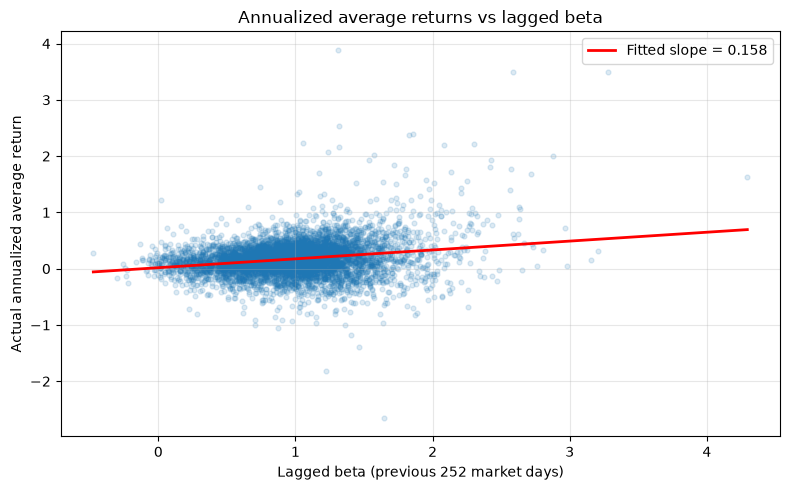

In [114]:
x = yearly_capm_results["lagged_beta"]
y = yearly_capm_results["actual_annualized_average_return"]

ols_sml = sm.OLS(y, sm.add_constant(x)).fit()
slope = ols_sml.params["lagged_beta"]
intercept = ols_sml.params["const"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.15, s=12)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, intercept + slope * x_line, color="red", linewidth=2, label=f"Fitted slope = {slope:.3f}")
plt.xlabel("Lagged beta (previous 252 market days)")
plt.ylabel("Actual annualized average return")
plt.title("Annualized average returns vs lagged beta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot of the stock levels shows a great deal of variation in the realised returns for stocks with similar levels of beta. As a result, it is difficult to identify the relationship between beta and return simply by looking at individual stocks. Much of this variation is probably due to firm-specific factors and can thus be eliminated by diversification.

In order to get a clearer picture of the relationship between beta and return, we use the method mentioned in the lecture. At the start of every year, the shares are divided into ten portfolios according to their beta, which had been estimated from the previous 252 trading days; Portfolio 1 consists of the stocks with the lowest beta and Portfolio 10 contains those with the highest beta. We then look at the returns of these portfolios in the subsequent year and calculate the average of these results over time. This helps to eliminate some of the noise associated with individual stocks and enables a clearer examination of the empirical Security Market Line.

In [115]:
beta_portfolio_rows = []  # Will hold results for each beta-sorted portfolio for each year

for year, year_df in yearly_capm_results.groupby("year"):
    if len(year_df) < 10:  # Need at least 10 stocks to form 10 portfolios
        continue
    year_df = year_df.copy()

    try:
        # Assign portfolio buckets by sorting stocks into 10 quantiles based on lagged_beta
        year_df["beta_portfolio"] = pd.qcut(year_df["lagged_beta"], 10, labels=range(1, 11), duplicates="drop").astype(int)
    except ValueError:  # e.g., not enough unique values for qcut
        continue

    year_mask = stock_daily_returns.index.year == year  # Select trading days for this year
    stock_year = stock_daily_returns.loc[year_mask]
    for portfolio_id, port_df in year_df.groupby("beta_portfolio"):
        tickers = port_df["ticker"].tolist()  # List of tickers in this beta portfolio

        # Calculate equal-weighted portfolio return for days where the stocks exist; skip days with all-NaN
        portfolio_daily = stock_year[tickers].mean(axis=1, skipna=True).dropna()
        if portfolio_daily.empty:  # No returns available for this portfolio and year
            continue

        realized_annual_return = (1 + portfolio_daily).prod() - 1  # Compound daily returns
        average_lagged_beta = port_df["lagged_beta"].mean()  # Average beta for this portfolio/year
        
        # Collect the results for this portfolio in this year
        beta_portfolio_rows.append({"year": year, "beta_portfolio": int(portfolio_id), "average_lagged_beta": average_lagged_beta, "realized_annual_return": realized_annual_return, "number_of_stocks": len(tickers)})

beta_portfolio_yearly_results = pd.DataFrame(beta_portfolio_rows)  # Final DataFrame: one row per portfolio per year

   beta_portfolio  average_beta  average_realized_return  number_of_years
0               1      0.330938                 0.108988               13
1               2      0.563584                 0.121342               13
2               3      0.711848                 0.137278               13
3               4      0.820575                 0.141601               13
4               5      0.919095                 0.153417               13
5               6      1.012977                 0.136987               13
6               7      1.107960                 0.172022               13
7               8      1.220691                 0.195637               13
8               9      1.374409                 0.191780               13
9              10      1.766509                 0.343809               13


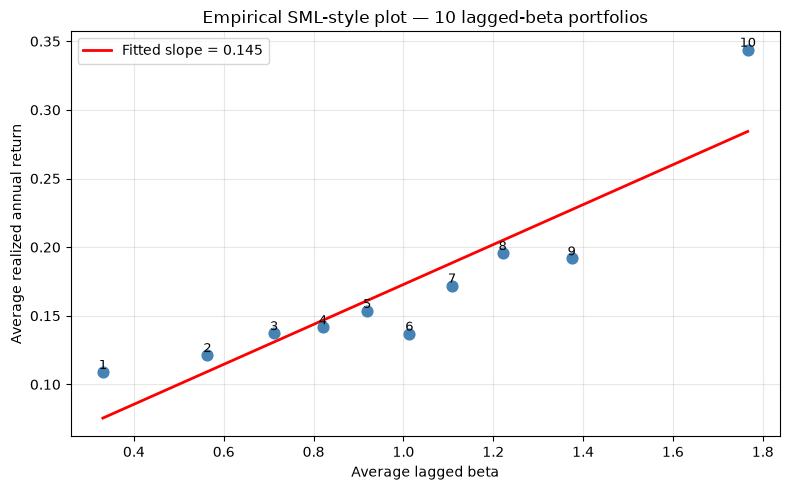

In [116]:
# Group beta portfolios and compute average characteristics for each group
beta_portfolio_grouped = beta_portfolio_yearly_results.groupby("beta_portfolio")

# Compute average beta, average realized annual return, and count of unique years for each portfolio
beta_portfolio_summary = beta_portfolio_grouped.agg(
    average_beta=("average_lagged_beta", "mean"),
    average_realized_return=("realized_annual_return", "mean"),
    number_of_years=("year", "nunique"),
)

# Reset the index to turn beta_portfolio into a column, and sort portfolios by their ID
beta_portfolio_summary = beta_portfolio_summary.reset_index()
beta_portfolio_summary = beta_portfolio_summary.sort_values("beta_portfolio")

# Show the summary statistics for all 10 beta portfolios
print(beta_portfolio_summary)


# Prepare the x (average beta) and y (average realized return) data for regression and plotting
x = beta_portfolio_summary["average_beta"]
y = beta_portfolio_summary["average_realized_return"]

# Add constant to x for regression intercept
x_with_const = sm.add_constant(x)

# Fit linear regression: realized return ~ average beta
ols_port = sm.OLS(y, x_with_const).fit()

# Extract slope and intercept from regression parameters
port_slope = ols_port.params["average_beta"]
port_intercept = ols_port.params["const"]


# Create figure for the scatter plot and regression line
plt.figure(figsize=(8, 5))

# Plot each portfolio's average beta vs. realized return as a scatter plot
plt.scatter(x, y, s=60, color="steelblue", zorder=3)

# Annotate each point with its portfolio number
for _, row in beta_portfolio_summary.iterrows():
    plt.text(
        row["average_beta"],
        row["average_realized_return"],
        str(int(row["beta_portfolio"])),
        fontsize=9,
        ha="center",
        va="bottom"
    )

# Generate x values for regression line
x_line = np.linspace(x.min(), x.max(), 100)

# Calculate y values from regression parameters for the regression line
y_line = port_intercept + port_slope * x_line

# Plot regression line on the same figure
plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=2,
    label=f"Fitted slope = {port_slope:.3f}"
)

# Label axes and add plot title
plt.xlabel("Average lagged beta")
plt.ylabel("Average realized annual return")
plt.title("Empirical SML-style plot — 10 lagged-beta portfolios")

# Add legend and a grid to the plot
plt.legend()
plt.grid(True, alpha=0.3)

# Improve layout before showing the plot
plt.tight_layout()
plt.show()

When the shares are divided into ten portfolios according to their lagged betas, the relationship between beta and return is clearer than it is in the analysis at the individual stock level. The slope of the fitted line is positive at 0.145, this is in agreement with the CAPM forecast that greater systematic risk should be linked to higher average returns.

The contrast between the low-beta and high-beta portfolios is especially clear: Portfolio 1 has an average beta of about 0.33 and an average annual return of approximately 11%, whereas Portfolio 10 has an average beta of about 1.77 and an average return of about 34%. It is therefore evident from the portfolio sorting that there is a positive relationship between beta and return which was hard to detect in the individual stock-year observations that were so noisy.

The relationship does not exhibit a perfect increasing trend in all ten portfolios. For instance, portfolios 6 and 9 have betas that are higher than those of the earlier portfolios but lower average returns. Hence, the results do not conform exactly to the theoretical Security Market Line; rather, they indicate a generally positive relationship between beta and return together with some variation that cannot be accounted for by beta alone.

This pattern is clearer when compared with the scatter of individual stocks, which shows the advantage of portfolio sorting. When a number of stocks are combined together in each beta group, the firm-specific variation is eliminated through diversification and thus the systematic relationship between beta and return becomes easier to see.

### Different time periods for Betas

   beta_window  mean_absolute_error  beta_return_correlation  n_stock_years
0          126             0.195152                 0.241134           6657
1          252             0.194226                 0.217646           6219
2          504             0.198522                 0.216753           5769


/var/folders/hf/wpyjr1gx2l5cb_tyndpj5wk00000gn/T/ipykernel_58979/2780503000.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


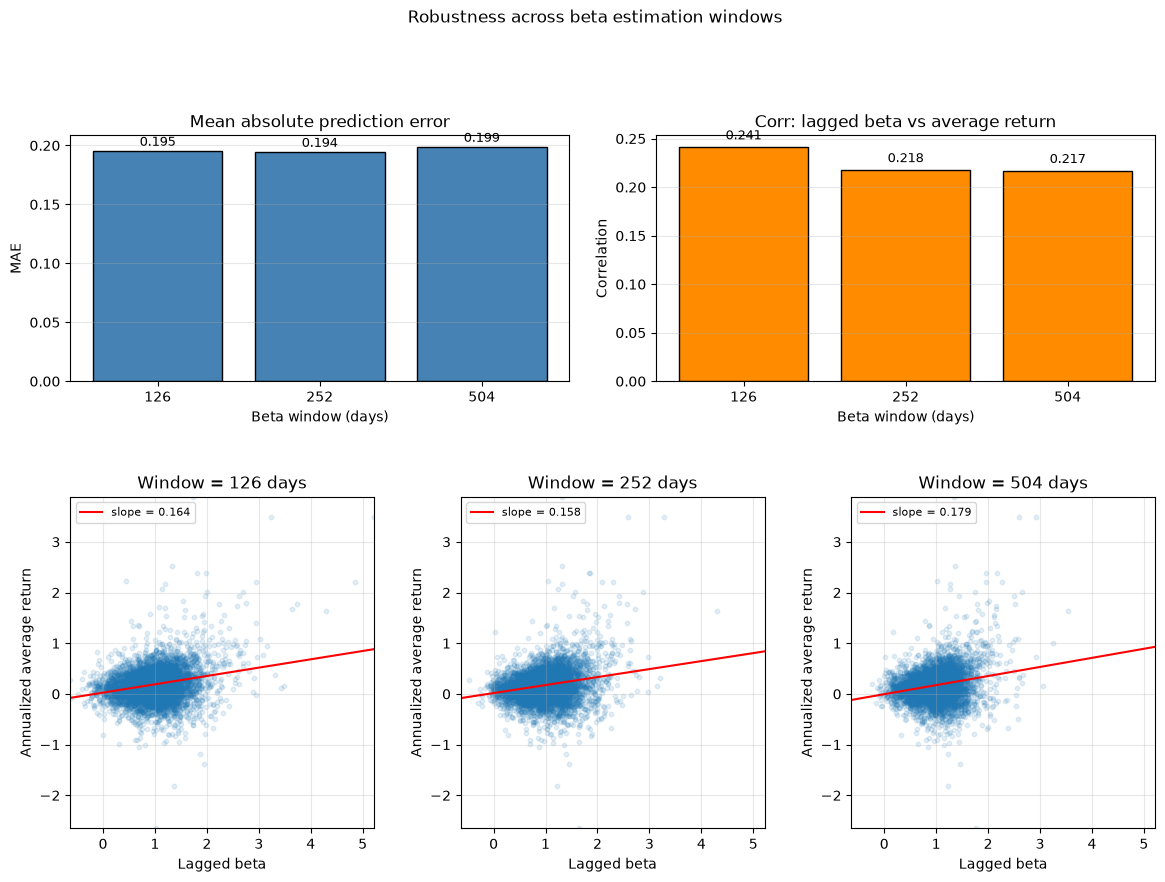

In [ ]:
# "Beta window" refers to how many trading days' worth of returns are used for each stock's beta calculation.
windows = [126, 252, 504]  # 126 days ≈ 6 months; 252 days ≈ 1 year (main case); 504 days ≈ 2 years
robustness_rows = []
panels_by_window = {}

# Loop over each window length to recompute the CAPM results
for beta_window in windows:
    # Calculate CAPM panel using each window length for beta estimation
    panel = build_yearly_capm_results(beta_window=beta_window)
    if panel.empty:
        continue

    # Store the result for scatter plotting later
    panels_by_window[beta_window] = panel

    # Compute summary metrics: mean absolute error, beta-return correlation, observation count
    mae = panel["prediction_error"].abs().mean()
    corr = panel["lagged_beta"].corr(panel["actual_annualized_average_return"])

    robustness_rows.append({
        "beta_window": beta_window,
        "mean_absolute_error": mae,
        "beta_return_correlation": corr,
        "n_stock_years": len(panel),
    })

# Combine metrics into a DataFrame for easier comparison/printing
robustness_table = pd.DataFrame(robustness_rows)

fig = plt.figure(figsize=(14, 9))
# Layout: two summary barplots and three scatterplots in a grid
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.35], hspace=0.4, wspace=0.8)
ax_mae = fig.add_subplot(gs[0, 0:3])    # Barplot: mean absolute error
ax_corr = fig.add_subplot(gs[0, 3:6])   # Barplot: correlation
ax_s126 = fig.add_subplot(gs[1, 0:2])   # Scatter: 126d window
ax_s252 = fig.add_subplot(gs[1, 2:4])   # Scatter: 252d window
ax_s504 = fig.add_subplot(gs[1, 4:6])   # Scatter: 504d window
scatter_axes = {126: ax_s126, 252: ax_s252, 504: ax_s504}

# Prepare x labels as strings for plotting
x_labels = robustness_table["beta_window"].astype(str)

# Barplot: Mean absolute error (how well CAPM predicts returns) 
ax_mae.bar(x_labels, robustness_table["mean_absolute_error"], color="steelblue", edgecolor="black")
ax_mae.set_title("Mean absolute prediction error\n(lower MAE = more accurate CAPM predictions)")
ax_mae.set_xlabel("Beta window (days)")
ax_mae.set_ylabel("MAE")
ax_mae.grid(True, alpha=0.3, axis="y")
# Annotate the top of each bar with its value (rounded to 3 decimals)
for i, value in enumerate(robustness_table["mean_absolute_error"]):
    ax_mae.text(i, value + 0.002, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

# Barplot: Correlation between lagged beta and realized return 
ax_corr.bar(x_labels, robustness_table["beta_return_correlation"], color="darkorange", edgecolor="black")
ax_corr.set_title("Corr: lagged beta vs average return\n(higher correlation = stronger CAPM relationship)")
ax_corr.set_xlabel("Beta window (days)")
ax_corr.set_ylabel("Correlation")
ax_corr.grid(True, alpha=0.3, axis="y")
for i, value in enumerate(robustness_table["beta_return_correlation"]):
    ax_corr.text(i, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

# Scatterplots: realized vs predicted returns for each window 
# For visual comparability, set same axis limits for all panels
all_panels = pd.concat(panels_by_window.values(), ignore_index=True)
x_min, x_max = all_panels["lagged_beta"].min(), all_panels["lagged_beta"].max()
y_min, y_max = all_panels["actual_annualized_average_return"].min(), all_panels["actual_annualized_average_return"].max()

for beta_window, ax in scatter_axes.items():
    panel = panels_by_window[beta_window]
    x = panel["lagged_beta"]
    y = panel["actual_annualized_average_return"]

    # Scatterplot: each point is a stock-year
    ax.scatter(x, y, alpha=0.12, s=10)
    # Add regression line: OLS fit of return ~ lagged beta
    fit = sm.OLS(y, sm.add_constant(x)).fit()
    x_line = np.linspace(x_min, x_max, 100)
    ax.plot(
        x_line,
        fit.params["const"] + fit.params["lagged_beta"] * x_line,
        color="red",
        linewidth=1.5,
        label=f"slope = {fit.params['lagged_beta']:.3f}",
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Window = {beta_window} days")
    ax.set_xlabel("Lagged beta")
    ax.set_ylabel("Annualized average return")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Robustness across beta estimation windows", y=1.02)
plt.tight_layout()
plt.show()


As a robustness check, we carry out the analysis again with beta estimation periods of 126, 252, and 504 trading days. The results are very similar in the three cases. The mean absolute prediction error stays at about 19 to 20 percentage points for all the periods in question, indicating that varying the beta estimation period does not substantially improve the accuracy with which the CAPM makes predictions.

The link between lagged beta and next year's average return is still positive. The beta-return correlation varies between about 0.22 and 0.24, and the fitted slopes are positive in each of the three estimation periods. The 126-day window gives a slightly higher correlation, this possibly suggesting that a shorter window picks up changes in beta more rapidly, but the difference is minor.

In summary, our primary conclusion remains valid regardless of the window used to estimate beta. In all three specifications a higher lagged beta is linked with higher subsequent average returns, although there is a great deal of variation in the individual stock returns that cannot be accounted for by beta alone.

### 3.5 Economic interpretation

The results offer only partial support for the CAPM. At the level of individual stocks, lagged beta and next-year returns are positively related, but this relationship is noisy. There is a correlation of approximately 0.45 between the returns predicted by the CAPM and the actual returns, and the average absolute prediction error is about 19.4 percentage points. Although beta does contain information on future returns in our sample, it is not enough for accurate predictions of returns.

The clarity of the relationship emerges when we apply the method described in the lecture and divide the stocks into ten portfolios according to their lagged betas. The portfolio with the lowest beta has an average return of about 11%, whereas the one with the highest beta has an average return of about 34%. The slope obtained from the fitted beta-return relationship is positive, which is in agreement with the CAPM's prediction that greater systematic risk should be linked to higher expected returns. Nevertheless, returns do not increase perfectly among all ten portfolios, so the empirical relationship is not as clear-cut as the theoretical Security Market Line. The lecture makes use of the same concept of sorting stocks into beta portfolios in order to test this relationship empirically. The fact that the beta-return relationship is much clearer when looking at the portfolio level also shows the effect of diversification. When shares are grouped into portfolios, the firm-specific shocks tend to cancel each other out, while their common exposure to market risk stays. As a result, the systematic part of the returns becomes easier to observe and this is in line with the CAPM notion that it is the systematic rather than the diversifiable risk which should be rewarded.

A possible reason for the remaining variation is that market risk might not be the only systematic risk factor. The lecture presents the APT as an alternative by allowing for multiple systematic factors rather than relying on just the market factor. This could account for the fact that stocks having the same market beta can still produce very different returns.

Finally, the robustness test indicates that the key finding is not very sensitive to the choice of the beta estimation window; whether 126, 252, or 504 trading days are used, the correlation between beta and return stays at about 0.22 to 0.24 and the prediction error remains near 19 to 20 percentage points. Although the positive relationship between beta and return seems to be robust, altering the estimation window has only a minor effect on the predictive accuracy of the CAPM.

In summary, our findings indicate that beta is important, but beta by itself is not sufficient. Although the CAPM shows a positive relationship between systematic risk and return, particularly after the firm-specific noise has been reduced by means of portfolio formation, it fails to account for the big variation in the returns of individual stocks.